# Descrição

Base de dados relacional.
Cada entidade (produto/product, pedido/order, corredor/aisle, ...) tem um ID único.
As colunas são "autoexplicativas"!

* **aisles.csv**


| aisle_id | aisle                      |
|----------|----------------------------|
| 1        | prepared soups salads       |
| 2        | specialty cheeses           |
| 3        | energy granola bars        |
| ...      | ...                        |


* **departments.csv**

| department_id | department |
|---------------|------------|
| 1             | frozen     |
| 2             | other      |
| 3             | bakery     |
| ...           | ...        |

* **order_products__*.csv**

Dois ficheiros: *_train.csv e *_prior.csv. 

Produtos/products encomendados em cada pedido/order.

"reordered" significa que o produto já havia sido encomendado antes.


| order_id | product_id | add_to_cart_order | reordered |
|----------|------------|-------------------|-----------|
| 1        | 49302      | 1                 | 1         |
| 1        | 11109      | 2                 | 1         |
| 1        | 10246      | 3                 | 0         |
| ...      | ...        | ...               | ...       |

* **orders.csv**  

"eval_set" - identifica em que dataset está o pedido (prior, train, test). 

"order_dow" - day of week



| order_id | user_id | eval_set | order_number | order_dow | order_hour_of_day | days_since_prior_order |
|----------|---------|----------|---------------|-----------|--------------------|------------------------|
| 2539329  | 1       | prior    | 1             | 2         | 08                 |                        |
| 2398795  | 1       | prior    | 2             | 3         | 07                 | 15.0                   |
| 473747   | 1       | prior    | 3             | 3         | 12                 | 21.0                   |
| ...      | ...     | ...      | ...           | ...       | ...                | ...                    |

* **products.csv**

| product_id | product_name                               | aisle_id | department_id |
|------------|--------------------------------------------|----------|---------------|
| 1          | Chocolate Sandwich Cookies                 | 61       | 19            |
| 2          | All-Seasons Salt                           | 104      | 13            |
| 3          | Robust Golden Unsweetened Oolong Tea      | 94       | 7             |
| ...        | ...                                        | ...      | ...           |

# Importar bibliotecas

In [2]:
# Importar bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Desativa warning
warnings.filterwarnings('ignore')

# Configura gráficos inline
%matplotlib inline

# Conteúdos da pasta
input_dir = "./data_mba"
print(os.listdir(input_dir))

# Instalar efficient_apriori 
# !pip install -q efficient_apriori

# Verifica e atualizar numba e visions
import numba
print("Versão do Numba:", numba.__version__)

from efficient_apriori import apriori

input_dir = "./data_mba"
print(os.listdir(input_dir))


['products.csv', 'departments.csv', 'order_products__prior.csv', 'orders.csv', 'aisles.csv', 'order_products__train.csv']
Versão do Numba: 0.60.0
['products.csv', 'departments.csv', 'order_products__prior.csv', 'orders.csv', 'aisles.csv', 'order_products__train.csv']


In [3]:
# !pip install ydata-profiling

# import ydata_profiling as pp

# Tenta importar pandas_profiling
# try:
#     import ydata_profiling as pp
# except AttributeError as e:
#     print("AttributeError:", e)
#     print("Considere atualizar sua versão do numba ou verificar problemas de compatibilidade.")


# Carregar os dados

In [4]:
# Carregar os dados
aisles_df = pd.read_csv("./data_mba/aisles.csv")
orders_df = pd.read_csv("./data_mba/orders.csv")
departments_df = pd.read_csv("./data_mba/departments.csv")
products_df = pd.read_csv("./data_mba/products.csv")
order_products_prior_df = pd.read_csv("./data_mba/order_products__prior.csv")
order_products_train_df = pd.read_csv("./data_mba/order_products__train.csv")

# Criar lista de dataframes para perfil
dataframes = {
    "aisles": aisles_df,
    "orders": orders_df,
    "departments": departments_df,
    "products": products_df,
    "order_products_prior": order_products_prior_df,
    "order_products_train": order_products_train_df
}

* **Mostrar colunas de cada DataFrame**

In [5]:
# Mostrar colunas de cada DataFrame
for name, df in dataframes.items():
    print(f"Colunas do DataFrame '{name}':")
    print(df.columns.tolist())
    print()  # Linha em branco para melhor legibilidade

Colunas do DataFrame 'aisles':
['aisle_id', 'aisle']

Colunas do DataFrame 'orders':
['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

Colunas do DataFrame 'departments':
['department_id', 'department']

Colunas do DataFrame 'products':
['product_id', 'product_name', 'aisle_id', 'department_id']

Colunas do DataFrame 'order_products_prior':
['order_id', 'product_id', 'add_to_cart_order', 'reordered']

Colunas do DataFrame 'order_products_train':
['order_id', 'product_id', 'add_to_cart_order', 'reordered']



# Extração de Características

* **Merge da Tabela order_product_prior com order, product, aisle e department.**

In [6]:
# DataFrame antes do merge

aisles_df.head(3)


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars


In [7]:
# DataFrame antes do merge

orders_df.head(3)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0


In [8]:
# DataFrame antes do merge

departments_df.head(3)


,department_id,department
0,1,frozen
1,2,other
2,3,bakery


In [9]:
# DataFrame antes do merge

products_df.head(3)


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7


In [10]:
# DataFrame antes do merge

order_products_prior_df.head(3)


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0


In [ ]:
# DataFrame antes do merge

order_products_train_df.head(3)


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0


: 

In [ ]:
#Merge
order_products_prior = order_products_prior_df.merge(orders_df, on='order_id', how='left')
order_products_prior = order_products_prior.merge(products_df, on='product_id', how='left')
order_products_prior = order_products_prior.merge(aisles_df, on='aisle_id', how='left')
order_products_prior = order_products_prior.merge(departments_df, on='department_id', how='left')


In [ ]:
#DataFrame após o merge
order_products_prior.head(3)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry


In [ ]:
#Missing values
order_products_prior.isna().sum()

order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64

In [ ]:
#Missing values em percentagem por coluna
order_products_prior.isnull().sum() / len(order_products_prior) * 100

order_id                  0.00000
product_id                0.00000
add_to_cart_order         0.00000
reordered                 0.00000
user_id                   0.00000
eval_set                  0.00000
order_number              0.00000
order_dow                 0.00000
order_hour_of_day         0.00000
days_since_prior_order    6.40697
product_name              0.00000
aisle_id                  0.00000
department_id             0.00000
aisle                     0.00000
department                0.00000
dtype: float64

#  Agrupar os dados em transações para aplicação do APRIORI.

In [ ]:
# Agrupar 'order_products_prior' por 'order_id', para criar um DataFrame com os IDs dos produtos de cada pedido.
order_grouped = pd.DataFrame(order_products_prior.groupby('order_id')['product_id'])


In [ ]:
#Mostra o numero de linhas e colunas
order_grouped.shape

(3214874, 2)

In [ ]:
len(order_grouped[0])

3214874

In [ ]:
order_grouped.head(3)

,0,1
0,2,0 33120 1 28985 2 9327 3 45918 4 ...
1,3,9 33754 10 24838 11 17704 12 2190...
2,4,17 46842 18 26434 19 39758 20 2776...


In [ ]:
# Lista
prod = []

for i in range(len(order_grouped[0])):
    prod.append(list(order_grouped.iloc[i][1]))
    
prod_ = prod
order_ = order_grouped[0]

In [ ]:
order_.head(10)

0     2
1     3
2     4
3     5
4     6
5     7
6     8
7     9
8    10
9    11
Name: 0, dtype: int64

In [ ]:
# Preparar o dataframe
transactions = pd.DataFrame({'OrderID' : order_, 'Products' : prod_})

In [ ]:
#ler os 10 primeiros valores
transactions.head(10)

,OrderID,Products
0,2,"[33120, 28985, 9327, 45918, 30035, 17794, 4014..."
1,3,"[33754, 24838, 17704, 21903, 17668, 46667, 174..."
2,4,"[46842, 26434, 39758, 27761, 10054, 21351, 225..."
3,5,"[13176, 15005, 47329, 27966, 23909, 48370, 132..."
4,6,"[40462, 15873, 41897]"
5,7,"[34050, 46802]"
6,8,[23423]
7,9,"[21405, 47890, 11182, 2014, 29193, 34203, 1499..."
8,10,"[24852, 4796, 31717, 47766, 4605, 1529, 21137,..."
9,11,"[30162, 27085, 5994, 1313, 31506]"


# Estatísticas Descritivas

### 1- Quantidade de Pedidos Mais Frequente entre os clientes

In [ ]:
# Agrupa os dados por cliente e número do pedido, agregando pelo maior valor
ord_max_count = orders_df.groupby("user_id")['order_number'].aggregate(np.max).reset_index()
ord_max_count.head(10)

,user_id,order_number
0,1,11
1,2,15
2,3,13
3,4,6
4,5,5
5,6,4
6,7,21
7,8,4
8,9,4
9,10,6


In [ ]:
# Conta por número de pedidos
ord_max_count = ord_max_count.order_number.value_counts()
ord_max_count.head(10)

order_number
4     23986
5     19590
6     16165
7     13850
8     11700
9     10190
10     9032
11     7815
12     6952
13     6236
Name: count, dtype: int64

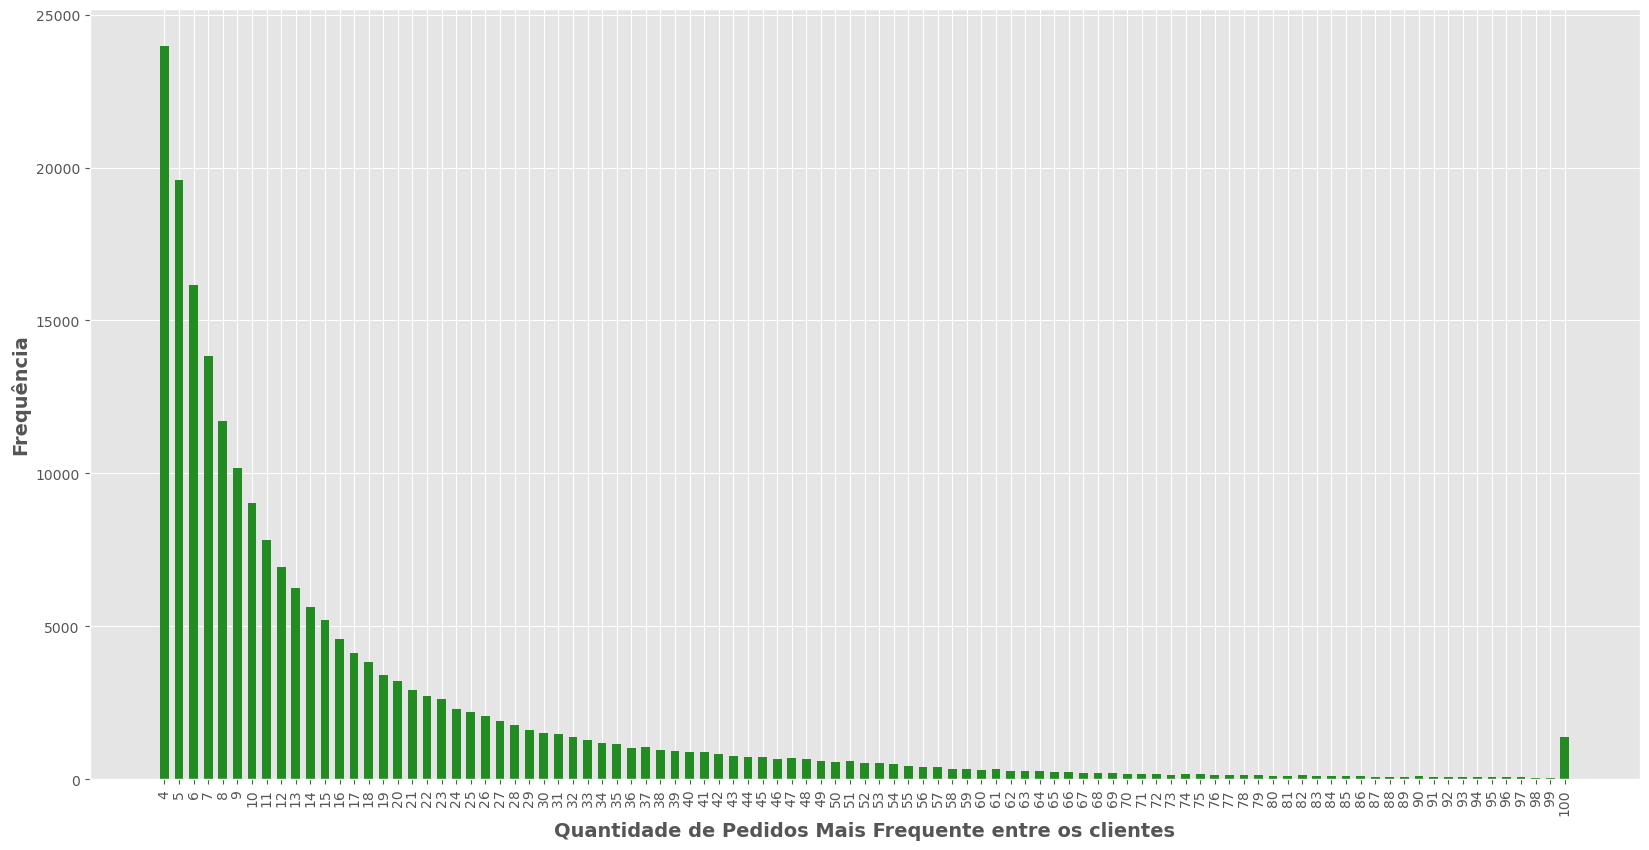

In [ ]:
# Plot
plt.style.use('ggplot')
plt.figure(figsize = (20,10))
plt.bar(ord_max_count.index, ord_max_count.values, color = 'forestgreen', width = 0.6)
plt.xticks(ord_max_count.index, rotation = 'vertical')
plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')
plt.xlabel('Quantidade de Pedidos Mais Frequente entre os clientes', fontsize = 14, fontweight = 'bold')
plt.show()

### 2- Dia da Semana com Maior Quantidade de Pedidos.

In [ ]:
# Frequências de pedidos por dia da semana (dow = day of the week)
x = [0,1,2,3,4,5,6]
y = [orders_df[orders_df['order_dow'] == 0].shape[0],
     orders_df[orders_df['order_dow'] == 1].shape[0],
     orders_df[orders_df['order_dow'] == 2].shape[0],
     orders_df[orders_df['order_dow'] == 3].shape[0],
     orders_df[orders_df['order_dow'] == 4].shape[0],
     orders_df[orders_df['order_dow'] == 5].shape[0],
     orders_df[orders_df['order_dow'] == 6].shape[0]]

In [ ]:
# Pedidos por dia da semana
y

[600905, 587478, 467260, 436972, 426339, 453368, 448761]

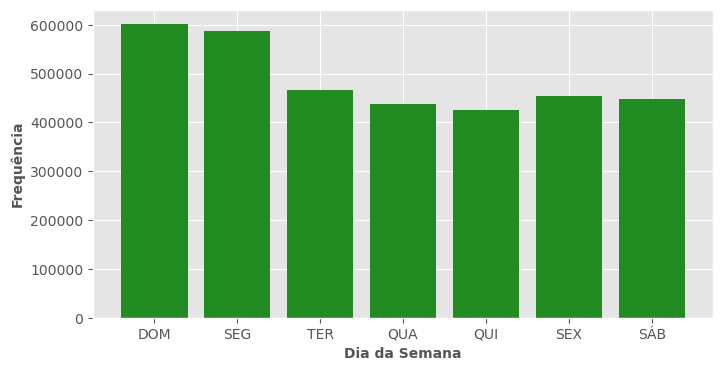

In [ ]:
# Plot
plt.figure(figsize = (8,4))
plt.bar(x,y, color = 'forestgreen')
plt.xlabel('Dia da Semana', fontsize = 10, fontweight = 'bold')
plt.ylabel('Frequência', fontsize = 10, fontweight = 'bold')
plt.xticks(x,['DOM', 'SEG', 'TER', 'QUA', 'QUI', 'SEX', 'SÁB'], rotation = 'horizontal')
plt.show()

### 3- Hora do Dia com Maior Quantidade de Pedidos

In [ ]:
# Frequências de pedidos pela hora do dia
x = list(range(0,24))
y = []
for i in range(24):
    y.append(orders_df[orders_df['order_hour_of_day']==i].shape[0])

In [ ]:
# Pedidos por hora do dia
y

[22758,
 12398,
 7539,
 5474,
 5527,
 9569,
 30529,
 91868,
 178201,
 257812,
 288418,
 284728,
 272841,
 277999,
 283042,
 283639,
 272553,
 228795,
 182912,
 140569,
 104292,
 78109,
 61468,
 40043]

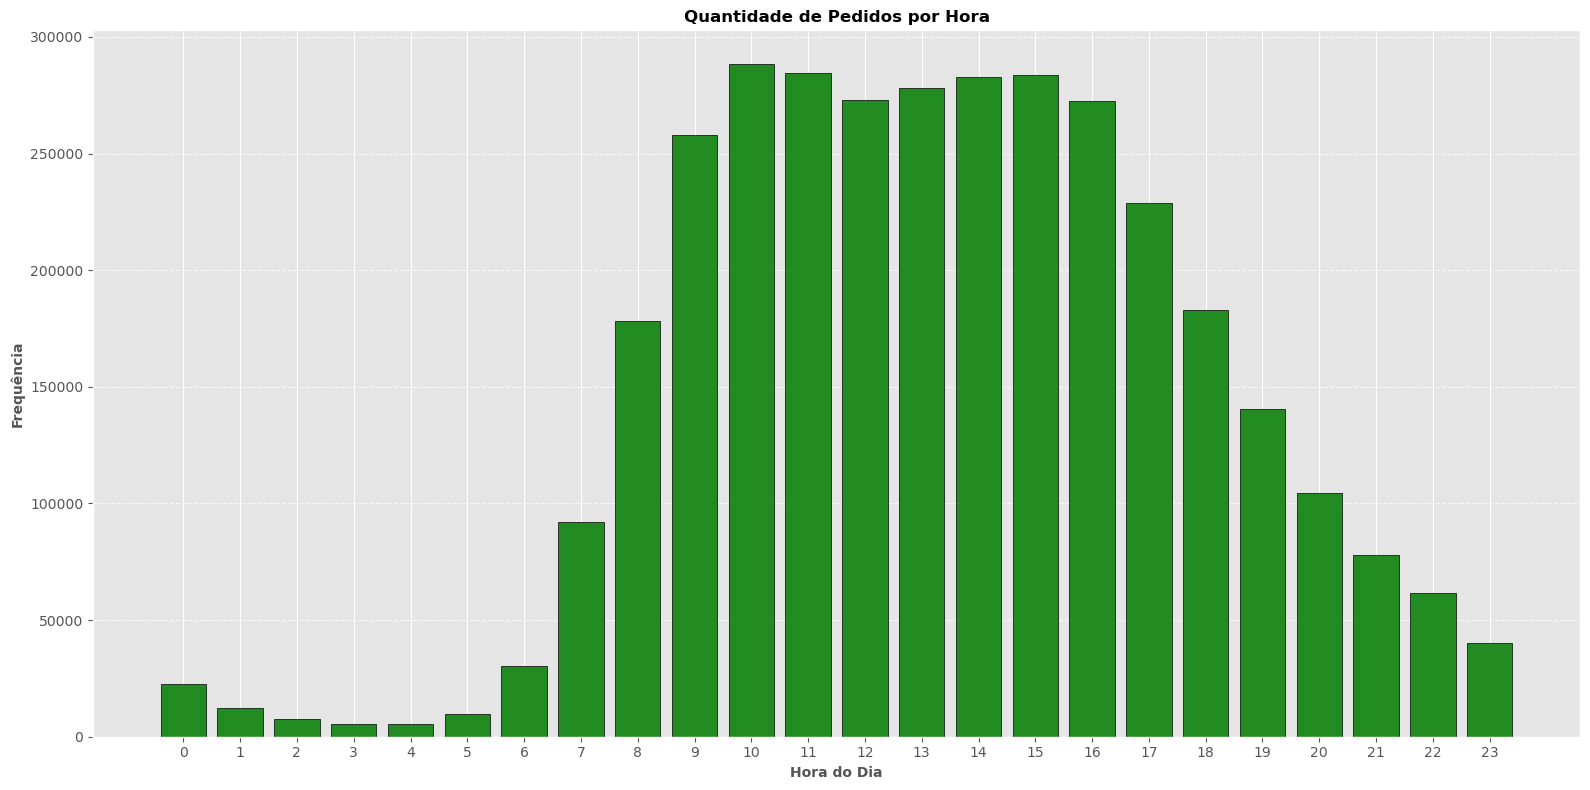

In [ ]:
# Plot
plt.figure(figsize=(16, 8))
plt.bar(x, y, color='forestgreen', edgecolor='black')

# Configurações dos eixos
plt.xticks(np.arange(0, 24, 1))
plt.xlabel('Hora do Dia', fontsize=10, fontweight='bold')
plt.ylabel('Frequência', fontsize=10, fontweight='bold')

# Título do gráfico
plt.title('Quantidade de Pedidos por Hora', fontsize=12, fontweight='bold')

# Adiciona uma grid para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostra o gráfico
plt.tight_layout()  # Ajusta o layout para evitar sobreposição
plt.show()

### 4- Departamento com Maior Quantidade de Pedidos

In [ ]:
# Contagem de pedidos por departamento
dept_cnt = order_products_prior['department'].value_counts()

In [ ]:
# Quantidade de pedidos por "department"
dept_cnt

department
produce            9479291
dairy eggs         5414016
snacks             2887550
beverages          2690129
frozen             2236432
pantry             1875577
bakery             1176787
canned goods       1068058
deli               1051249
dry goods pasta     866627
household           738666
breakfast           709569
meat seafood        708931
personal care       447123
babies              423802
international       269253
alcohol             153696
pets                 97724
missing              69145
other                36291
bulk                 34573
Name: count, dtype: int64

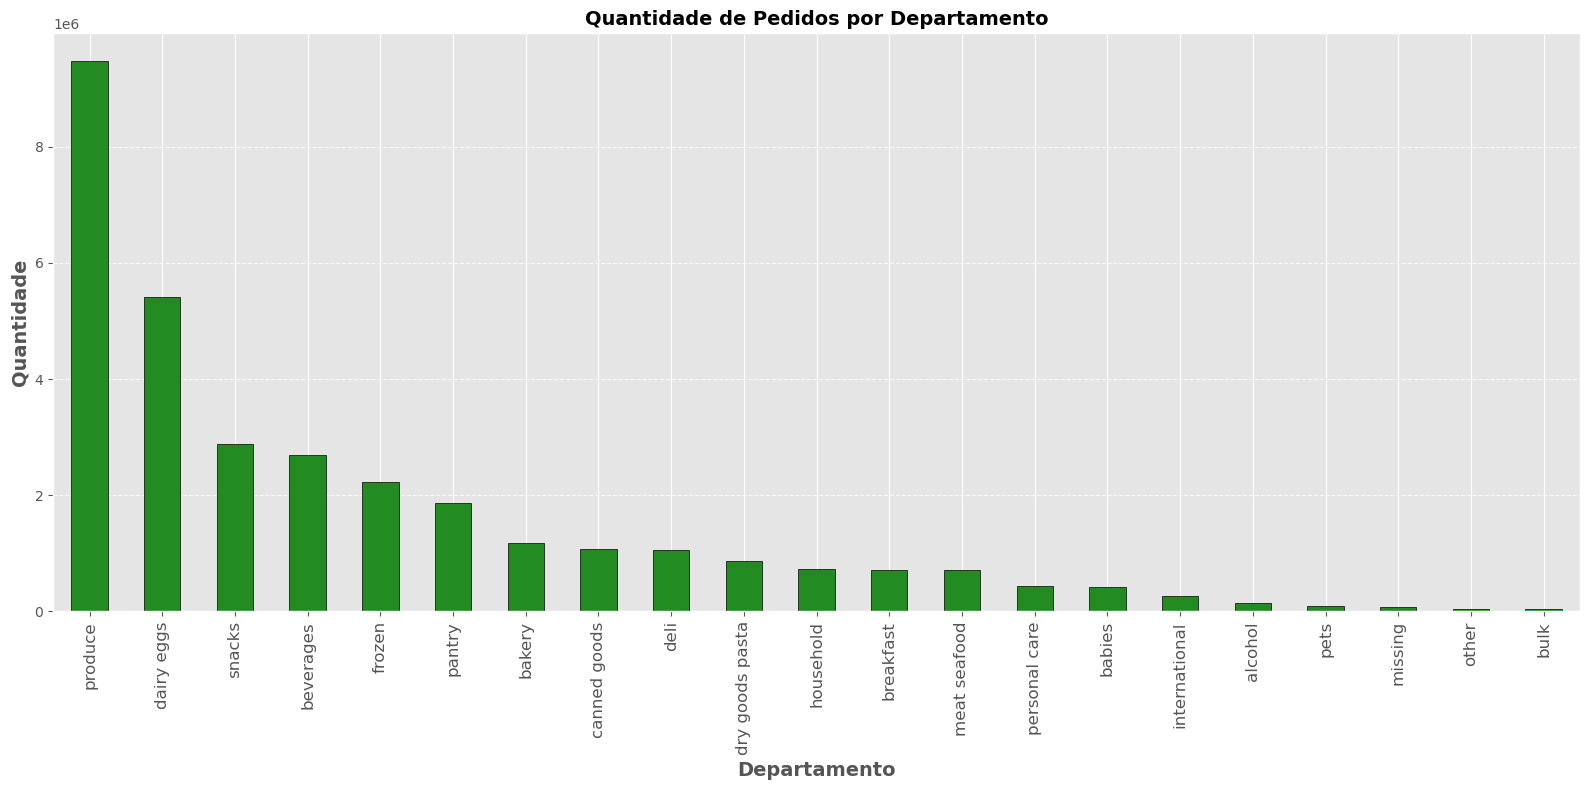

In [ ]:
# Plot
fig = plt.figure(figsize=(16, 8))
dept_cnt.plot(kind="bar", color='forestgreen', edgecolor='black')

# Configurações dos eixos
plt.xticks(rotation=90, fontsize=12)
plt.xlabel('Departamento', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade', fontsize=14, fontweight='bold')

# Título do gráfico
plt.title('Quantidade de Pedidos por Departamento', fontsize=14, fontweight='bold')

# Adiciona uma grid para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajusta o layout para evitar sobreposição
plt.tight_layout()

# Mostra o gráfico
plt.show()

### 5- Top 20 Principais Corredores Por Frequência de Pedidos.

In [ ]:
# Os 20 principais corredores e sua frequência de pedidos
aisle_cnt = order_products_prior['aisle'].value_counts()

In [ ]:
# Quantidade de pedidos por corredor/aisle
aisle_cnt[0:20]

aisle
fresh fruits                     3642188
fresh vegetables                 3418021
packaged vegetables fruits       1765313
yogurt                           1452343
packaged cheese                   979763
milk                              891015
water seltzer sparkling water     841533
chips pretzels                    722470
soy lactosefree                   638253
bread                             584834
refrigerated                      575881
frozen produce                    522654
ice cream ice                     498425
crackers                          458838
energy granola bars               456386
eggs                              452134
lunch meat                        395130
frozen meals                      390299
baby food formula                 382456
fresh herbs                       377741
Name: count, dtype: int64

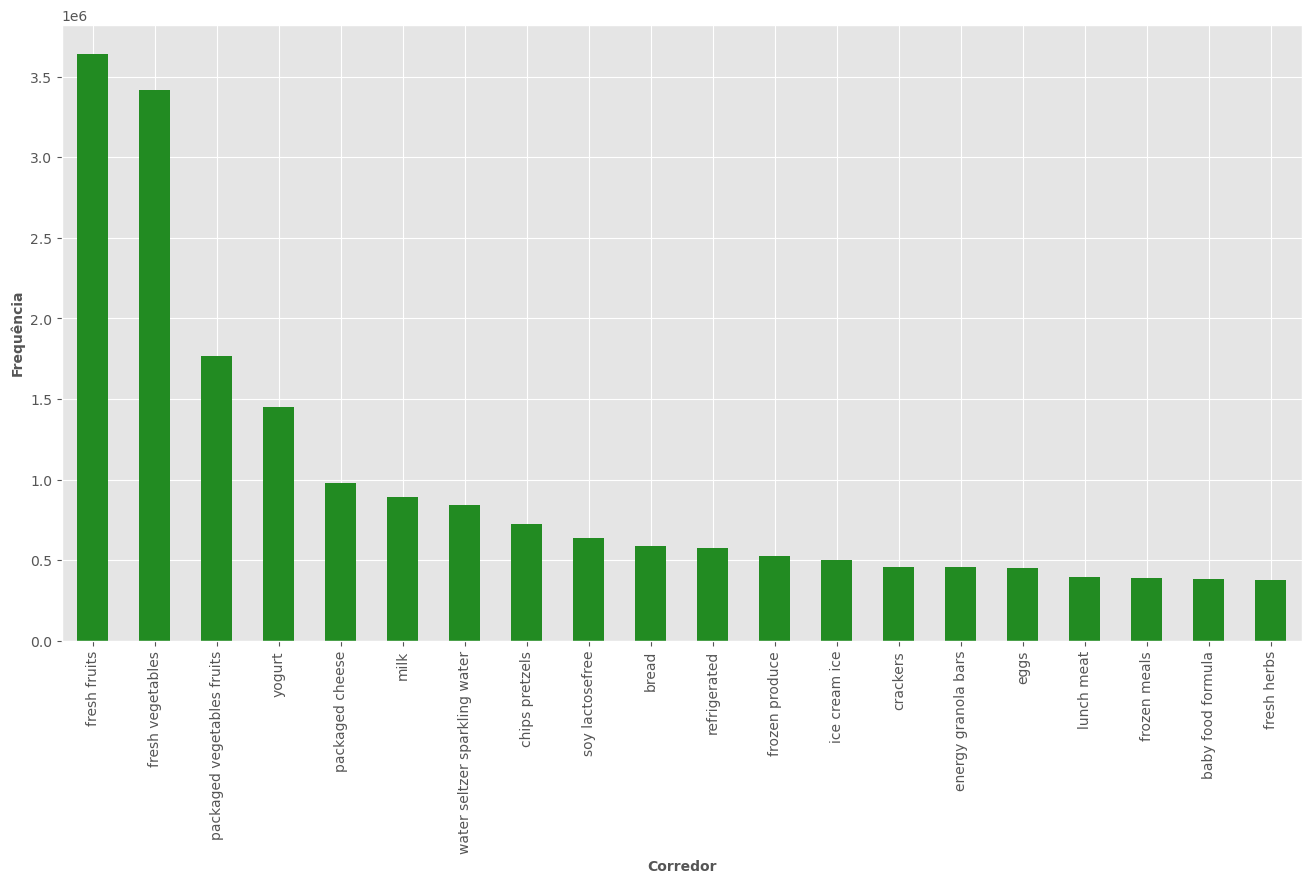

In [ ]:
# Plot
fig = plt.figure(figsize = (16,8))
aisle_cnt[0:20].plot(kind = "bar", color = 'forestgreen')
plt.xticks(rotation = 90)
plt.xlabel('Corredor', fontsize = 10, fontweight = 'bold')
plt.ylabel('Frequência', fontsize = 10, fontweight = 'bold')
plt.show()

### 6- Top 20 Principais Produtos Por Frequência de Pedidos.

In [ ]:
# Top 20 principais produtos por frequência de pedido
prod_cnt = order_products_prior['product_name'].value_counts()

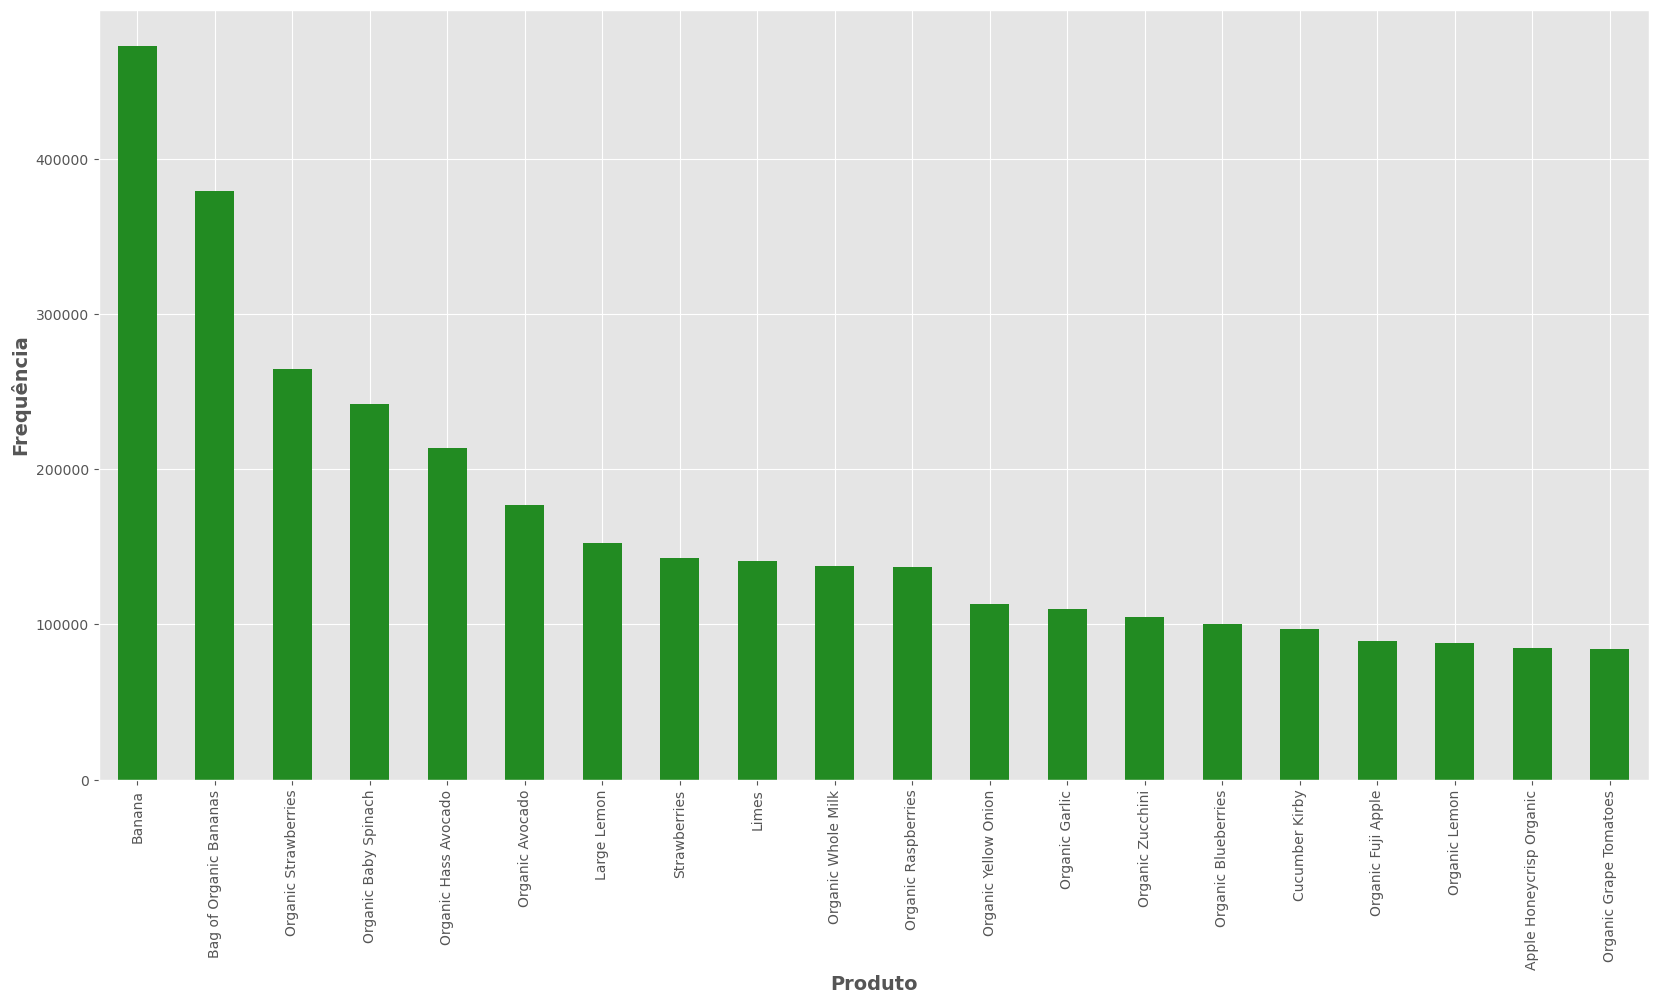

In [ ]:
# Plot
fig = plt.figure(figsize = (20,10))
prod_cnt[0:20].plot(kind = "bar", color = 'forestgreen')
plt.xticks(rotation = 90)
plt.xlabel('Produto', fontsize = 14, fontweight = 'bold')
plt.ylabel('Frequência', fontsize = 14, fontweight = 'bold')
plt.show()

In [ ]:
temp_df = order_products_prior.groupby("product_name")["reordered"].agg(['count', 'sum']).rename(columns = {'count':'total','sum':'reorders'})
temp_df = temp_df.sort_values('total', ascending = False).reset_index()

In [ ]:
# Prepara as listas
labels = list(temp_df.product_name[0:20])
reorder = list(temp_df.reorders[0:20])
total = list(temp_df.total[0:20])

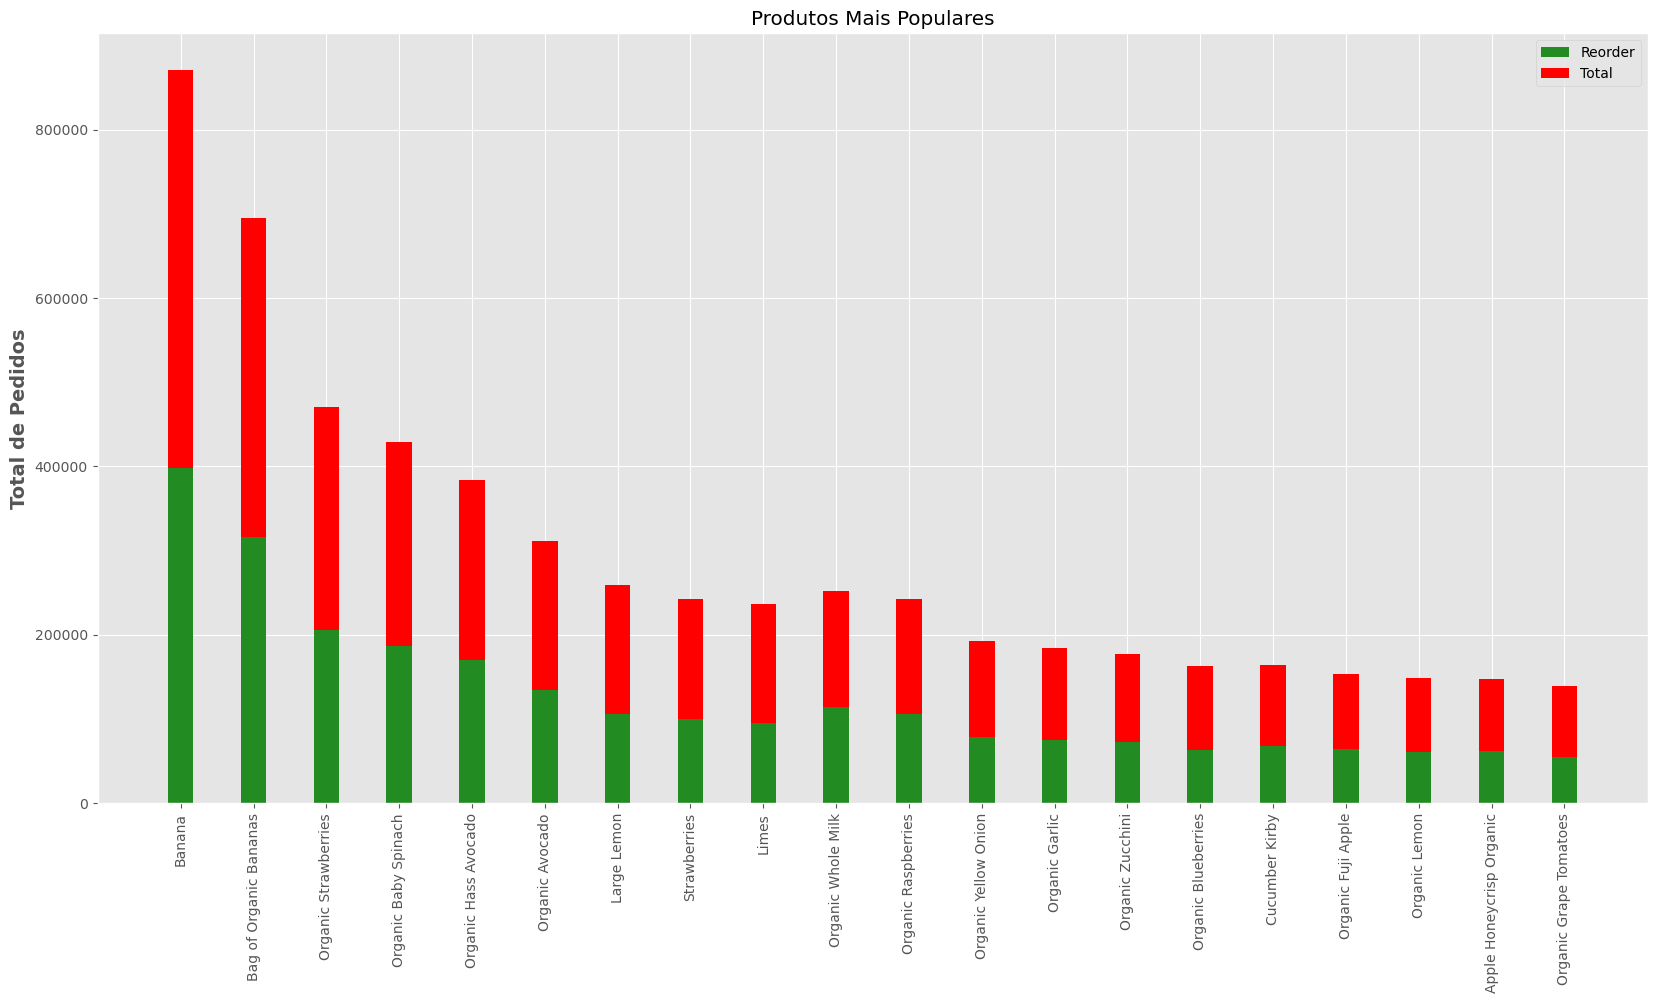

In [ ]:
# Plot  
width = 0.35 
fig, ax = plt.subplots(figsize = (20,10))
ax.bar(labels, reorder, width, label = 'Reorder', color = 'forestgreen')
ax.bar(labels, total, width, bottom = reorder, label = 'Total', color = 'red')
ax.set_ylabel('Total de Pedidos', fontsize = 14, fontweight = 'bold')
ax.legend()
ax.set_title("Produtos Mais Populares")
plt.xticks(rotation = 90)
plt.show()

In [ ]:
# Agrupando os dados por departamento e reorder
grouped_df = order_products_prior.groupby(["department"])["reordered"].aggregate("mean").reset_index()
grouped_df.head()

,department,reordered
0,alcohol,0.569924
1,babies,0.578971
2,bakery,0.628141
3,beverages,0.653460
4,breakfast,0.560922


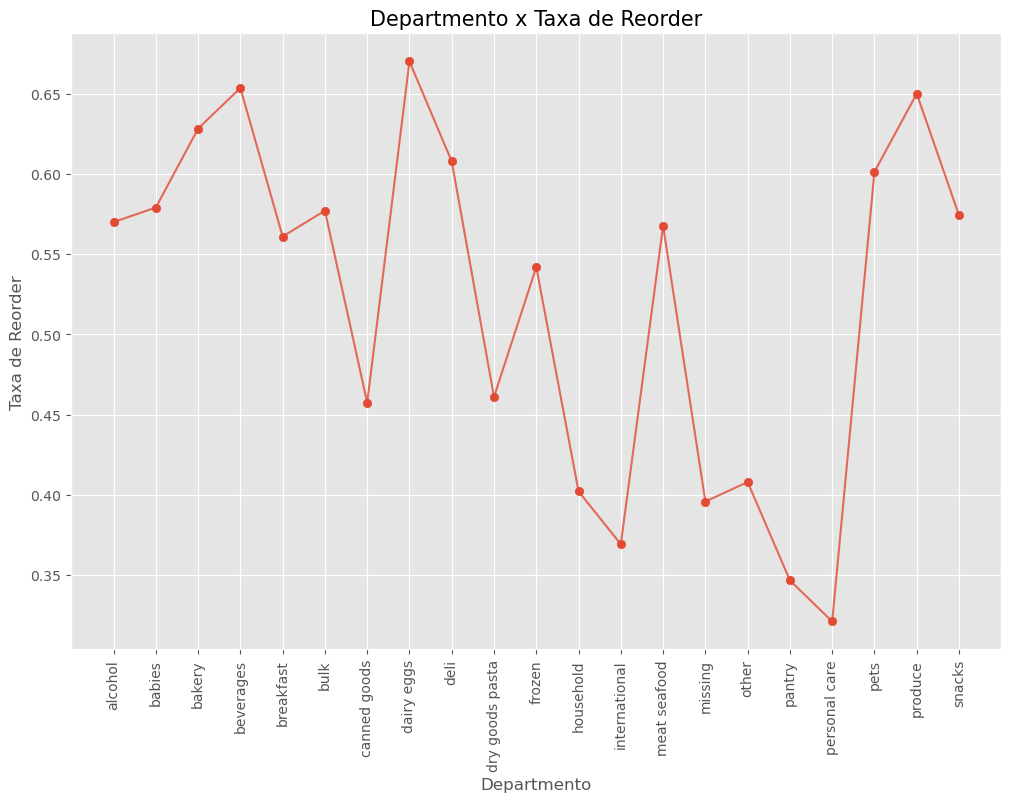

In [ ]:
# Plot
plt.figure(figsize = (12,8))
plt.plot(list(grouped_df['department']), grouped_df['reordered'].values, alpha=0.8)
plt.scatter(list(grouped_df['department']), grouped_df['reordered'].values)
plt.ylabel('Taxa de Reorder', fontsize = 12)
plt.xlabel('Departmento', fontsize = 12)
plt.title("Departmento x Taxa de Reorder", fontsize = 15)
plt.xticks(rotation = 'vertical')
plt.show()

In [ ]:
temp_df = order_products_prior.groupby("department")["reordered"].agg(['count', 'sum']).rename(columns = {'count':'total','sum':'reorders'})
temp_df = temp_df.sort_values('total', ascending = False).reset_index()

In [ ]:
temp_df.head(10)

,department,total,reorders
0,produce,9479291,6160710
1,dairy eggs,5414016,3627221
2,snacks,2887550,1657973
3,beverages,2690129,1757892
4,frozen,2236432,1211890
5,pantry,1875577,650301
6,bakery,1176787,739188
7,canned goods,1068058,488535
8,deli,1051249,638864
9,dry goods pasta,866627,399581


In [ ]:
# Listas
labels = list(temp_df.department[0:20])
reorder = list(temp_df.reorders[0:20])
total = list(temp_df.total[0:20])

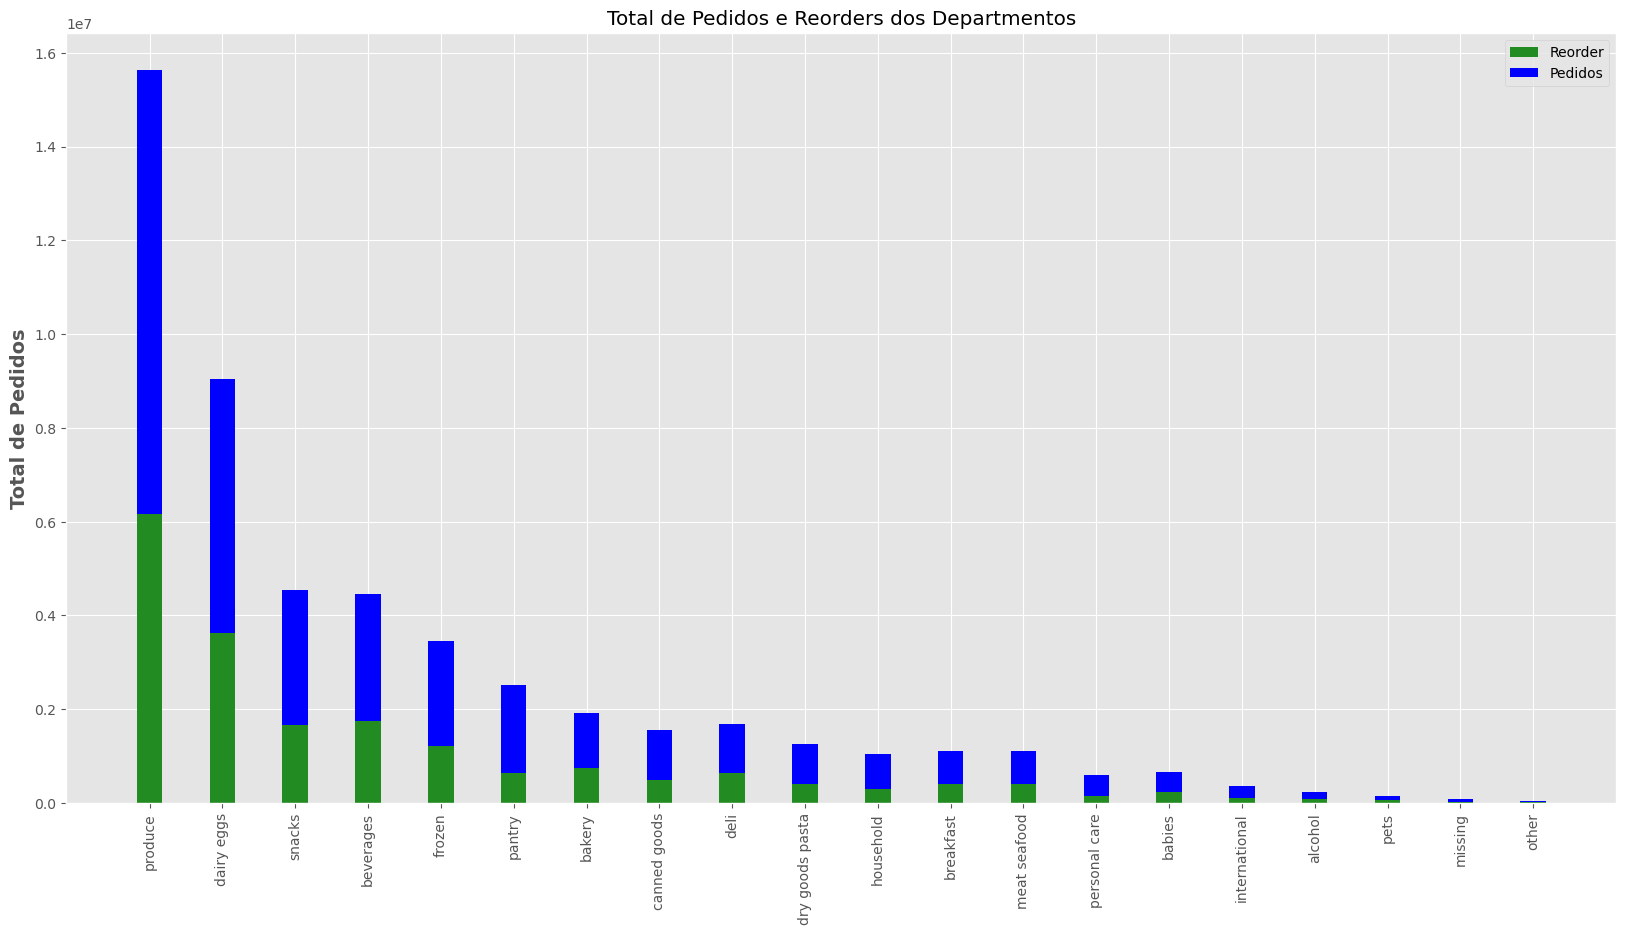

In [ ]:
# Plot
width = 0.35  
fig, ax = plt.subplots(figsize = (20,10))
ax.bar(labels, reorder, width, label = 'Reorder', color = 'forestgreen')
ax.bar(labels, total, width, bottom = reorder, label = 'Pedidos', color = 'blue')
ax.set_ylabel('Total de Pedidos', fontsize = 14, fontweight = 'bold')
ax.legend()
ax.set_title("Total de Pedidos e Reorders dos Departmentos")
plt.xticks(rotation = 90)
plt.show()

In [ ]:
grouped_df = order_products_prior.groupby(["aisle"])["reordered"].aggregate("mean").reset_index()
grouped_df.head(10)

,aisle,reordered
0,air fresheners candles,0.309052
1,asian foods,0.351132
2,baby accessories,0.550980
3,baby bath body care,0.295770
4,baby food formula,0.590259
5,bakery desserts,0.499125
6,baking ingredients,0.305082
7,baking supplies decor,0.167229
8,beauty,0.212062
9,beers coolers,0.565304


In [ ]:
list(grouped_df['aisle'])[0:20]

['air fresheners candles',
 'asian foods',
 'baby accessories',
 'baby bath body care',
 'baby food formula',
 'bakery desserts',
 'baking ingredients',
 'baking supplies decor',
 'beauty',
 'beers coolers',
 'body lotions soap',
 'bread',
 'breakfast bakery',
 'breakfast bars pastries',
 'bulk dried fruits vegetables',
 'bulk grains rice dried goods',
 'buns rolls',
 'butter',
 'candy chocolate',
 'canned fruit applesauce']

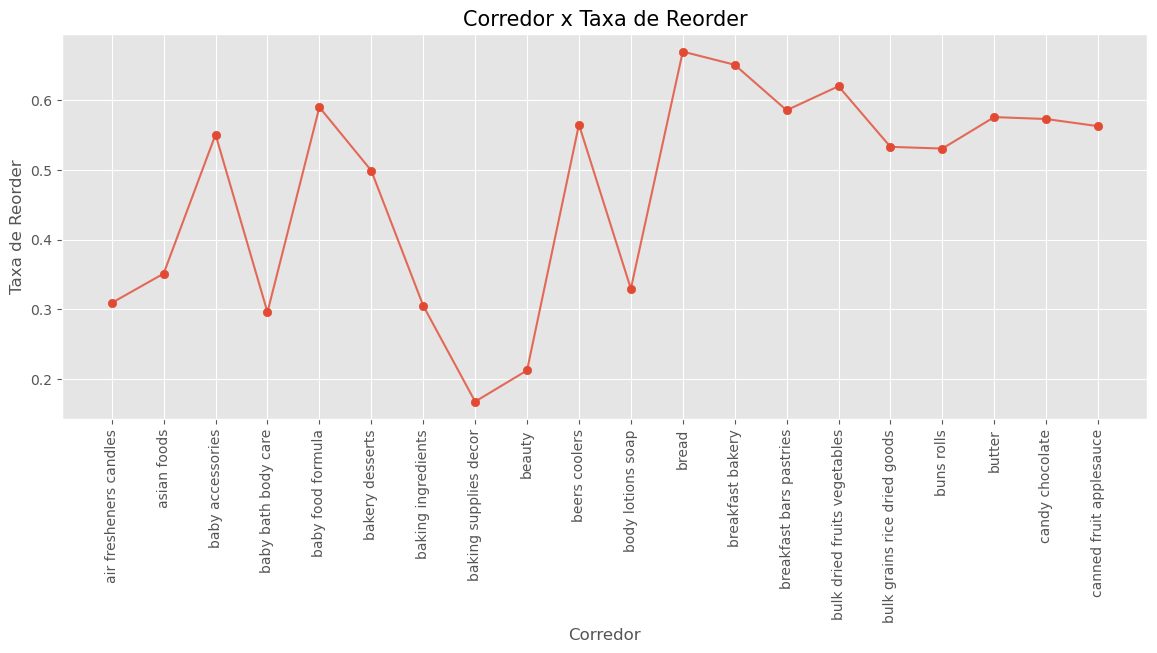

In [ ]:
# Corredor x Taxa de Reorder
plt.figure(figsize=(14,5))
plt.plot(list(grouped_df['aisle'])[0:20], grouped_df['reordered'].values[0:20], alpha=0.8)
plt.scatter(list(grouped_df['aisle'])[0:20], grouped_df['reordered'].values[0:20])
plt.ylabel('Taxa de Reorder', fontsize=12)
plt.xlabel('Corredor', fontsize=12)
plt.title("Corredor x Taxa de Reorder", fontsize = 15)
plt.xticks(rotation = 'vertical')
plt.show()

In [ ]:
temp_df = order_products_prior.groupby("aisle")["reordered"].agg(['count', 'sum']).rename(columns = {'count':'total','sum':'reorders'})
temp_df = temp_df.sort_values('total', ascending = False).reset_index()


In [ ]:
temp_df.head(10)

,aisle,total,reorders
0,fresh fruits,3642188,2615469
1,fresh vegetables,3418021,2032172
2,packaged vegetables fruits,1765313,1127177
3,yogurt,1452343,997018
4,packaged cheese,979763,573383
5,milk,891015,696264
6,water seltzer sparkling water,841533,613977
7,chips pretzels,722470,425387
8,soy lactosefree,638253,442023
9,bread,584834,391937


In [ ]:
# Listas
labels = list(temp_df.aisle[0:20])
reorder = list(temp_df.reorders[0:20])
total = list(temp_df.total[0:20])

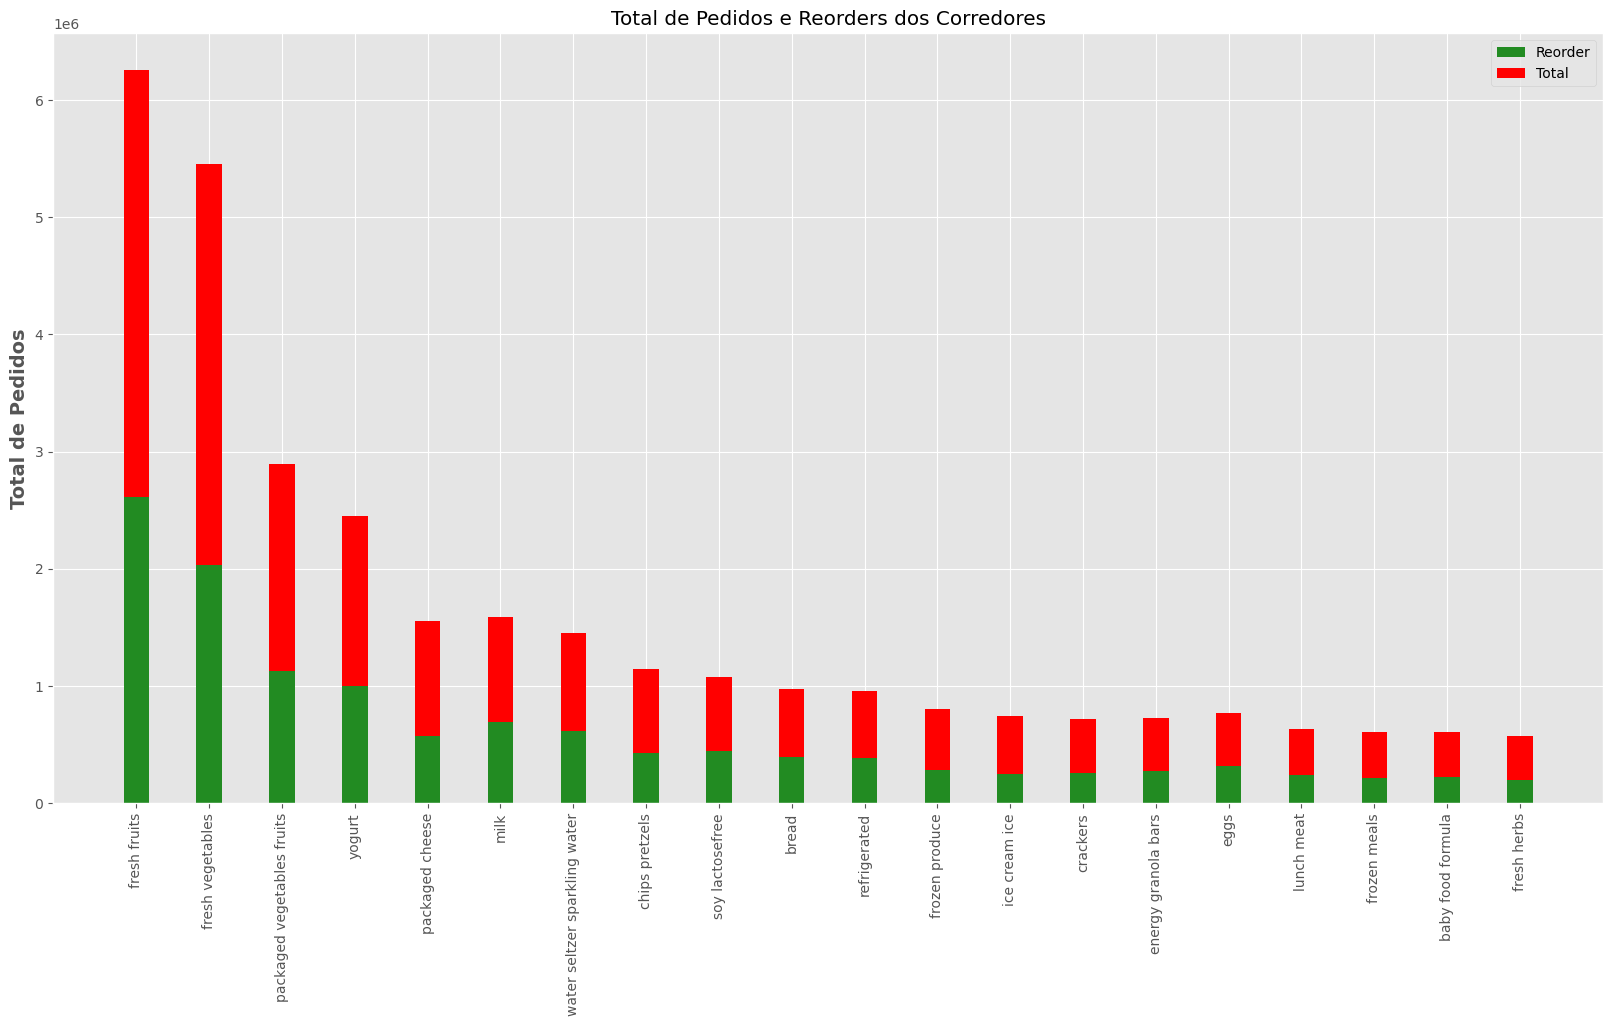

In [ ]:
# Plot
width = 0.35      
fig, ax = plt.subplots(figsize = (20,10))
ax.bar(labels, reorder, width, label = 'Reorder', color = 'forestgreen')
ax.bar(labels, total, width, bottom = reorder, label = 'Total', color = 'red')
ax.set_ylabel('Total de Pedidos', fontsize = 14, fontweight = 'bold')
ax.legend()
ax.set_title("Total de Pedidos e Reorders dos Corredores")
plt.xticks(rotation = 90)
plt.show()

Verificando a relação entre como a ordem de adição do produto ao carrinho afeta a proporção de novos pedidos

In [ ]:
#Ignorando avisos.
!pip install -q shutup
import warnings
warnings.filterwarnings('ignore')
import shutup; shutup.please()

In [ ]:
order_products_prior["add_to_cart_order_mod"] = order_products_prior["add_to_cart_order"].copy()
order_products_prior["add_to_cart_order_mod"].loc[order_products_prior["add_to_cart_order_mod"] > 70] = 70
grouped_df = order_products_prior.groupby(["add_to_cart_order_mod"])["reordered"].aggregate("mean").reset_index()

In [ ]:
grouped_df.head(10)

,add_to_cart_order_mod,reordered
0,1,0.677533
1,2,0.676251
2,3,0.658037
3,4,0.636958
4,5,0.617383
5,6,0.600420
6,7,0.585687
7,8,0.573247
8,9,0.561474
9,10,0.551018


# Implementação do Algoritmo Apriori.


**Suporte (Support)**:  
Support(A, B) = frq (A, B) / N  
Onde frq (A, B) é a frequência de itens A e B juntos, e N é o total de transações.

---

**Confiança (Confidence)**:  
Confidence(A → B) = frq (A, B) / frq (A)  
A confiança mede a probabilidade de B acontecer, dado que A aconteceu.

---

**Lift**:  
Lift(A → B) = Support(A, B) / (Support(A) × Support(B))  
O lift mede a força da associação entre A e B em comparação com a independência.

---


In [ ]:
# Para relembrar o que foi feito com as transações/transactions
transactions[0:10]

,OrderID,Products
0,2,"[33120, 28985, 9327, 45918, 30035, 17794, 4014..."
1,3,"[33754, 24838, 17704, 21903, 17668, 46667, 174..."
2,4,"[46842, 26434, 39758, 27761, 10054, 21351, 225..."
3,5,"[13176, 15005, 47329, 27966, 23909, 48370, 132..."
4,6,"[40462, 15873, 41897]"
5,7,"[34050, 46802]"
6,8,[23423]
7,9,"[21405, 47890, 11182, 2014, 29193, 34203, 1499..."
8,10,"[24852, 4796, 31717, 47766, 4605, 1529, 21137,..."
9,11,"[30162, 27085, 5994, 1313, 31506]"


In [ ]:
# Prepara o tuplo com as transações
transactions_tup = [tuple(row) for row in transactions['Products'].tolist()]

### Executa o Algoritmo Apriori Com Support = 0.01 e Confidence = 0.2.

In [ ]:
from datetime import datetime
from itertools import combinations
import efficient_apriori
from efficient_apriori import apriori

st = datetime.now()
itemsets_ap, rules_ap = apriori(transactions_tup[:500000], min_support = 0.01, min_confidence = 0.2)
print('Tempo de Execução : ', datetime.now() - st)

Tempo de Execução :  0:00:03.206939


In [ ]:
rules_ap

[{21137} -> {13176},
 {21903} -> {13176},
 {27966} -> {13176},
 {47209} -> {13176},
 {16797} -> {24852},
 {21137} -> {24852},
 {27966} -> {21137},
 {21903} -> {24852},
 {28204} -> {24852},
 {47626} -> {24852},
 {47766} -> {24852},
 {49683} -> {24852}]

In [ ]:
# Criação do DataFrame temporário
temp = pd.DataFrame()

# Listas de itens para considerar
# item_A = [27966, 47209, 21137, 47766, 21903, 49683, 47626, 28204, 16797, 21903, 21137, 27966]
# item_B = [13176, 13176, 24852, 24852, 24852, 24852, 24852, 24852, 24852, 13176, 13176, 21137]

item_A = [21137, 21903, 27966, 47209, 16797, 21137, 27966, 21903, 28204, 47626, 47766, 49683]
item_B = [13176, 13176, 13176, 13176, 24852, 24852, 21137, 24852, 24852, 24852, 24852, 24852]

# Adiciona as listas ao DataFrame
temp['itemA'] = item_A
temp['itemB'] = item_B


In [ ]:
# Listas para as métricas
support_A = []
support_B = []
support_AB = []
confidence_AB = []
lift_AB = []

In [ ]:
# Loop
for i in range(len(temp)):
    
    # Calcula o support de A
    support_A.append(itemsets_ap[1][tuple([temp['itemA'][i],])] / 500000)
    
    # Calcula o support de B
    support_B.append(itemsets_ap[1][tuple([temp['itemB'][i],])] / 500000)
    
    # Calcula o support de A e B
    if tuple([temp['itemA'][i],temp['itemB'][i]]) in itemsets_ap[2].keys():
        support_AB.append(itemsets_ap[2][tuple([temp['itemA'][i],temp['itemB'][i]])] / 500000)
    else:
        support_AB.append(itemsets_ap[2][tuple([temp['itemB'][i],temp['itemA'][i]])] / 500000)
    
    # Calcula a confidence
    confidence_AB.append(support_AB[i] / support_A[i])
    
    # Calcula o lift
    lift_AB.append(support_AB[i] / (support_A[i] * support_B[i]))

In [ ]:
# Criando DataFrame com as regras de associação
rules_df = pd.DataFrame({
    'Item A': temp['itemA'],
    'Item B': temp['itemB'],
    'Support A': support_A,
    'Support B': support_B,
    'Support AB': support_AB,
    'Confidence AB': confidence_AB,
    'Lift AB': lift_AB
})

# Exibe as regras de associação
print("\nRegras de Associação:")
print(rules_df)


Regras de Associação:
    Item A  Item B  Support A  Support B  Support AB  Confidence AB   Lift AB
0    21137   13176   0.082550   0.117802    0.019122       0.231641  1.966362
1    21903   13176   0.075000   0.117802    0.015500       0.206667  1.754356
2    27966   13176   0.042334   0.117802    0.012428       0.293570  2.492064
3    47209   13176   0.066218   0.117802    0.019260       0.290857  2.469037
4    16797   24852   0.044496   0.147194    0.012902       0.289959  1.969908
5    21137   24852   0.082550   0.147194    0.017596       0.213156  1.448127
6    27966   21137   0.042334   0.082550    0.010524       0.248595  3.011442
7    21903   24852   0.075000   0.147194    0.016016       0.213547  1.450784
8    28204   24852   0.027942   0.147194    0.010630       0.380431  2.584554
9    47626   24852   0.047718   0.147194    0.012692       0.265979  1.806998
10   47766   24852   0.054564   0.147194    0.016328       0.299245  2.032997
11   49683   24852   0.030218   0.147194 

In [ ]:
# Dataframe com as regras de associação
df_rules_ap = pd.DataFrame()
df_rules_ap['product_id'] = item_A
df_rules_ap = df_rules_ap.merge(products_df, on = 'product_id', how = 'left')
df_rules_ap['Product_A'] = df_rules_ap['product_name']
df_rules_ap = df_rules_ap.drop(columns = ['product_id','product_name','aisle_id','department_id'], axis = 1)
df_rules_ap['product_id'] = item_B
df_rules_ap = df_rules_ap.merge(products_df, on = 'product_id', how = 'left')
df_rules_ap['Product_B'] = df_rules_ap['product_name']
df_rules_ap = df_rules_ap.drop(columns = ['product_id','product_name','aisle_id','department_id'], axis = 1)
df_rules_ap['Support_A'] = support_A
df_rules_ap['Support_B'] = support_B
df_rules_ap['Support_AB'] = support_AB
df_rules_ap['Confidence_AB'] = confidence_AB
df_rules_ap['Lift_AB'] = lift_AB

In [ ]:
df_rules_ap.sort_values(by = 'Confidence_AB', ascending = False)

,Product_A,Product_B,Support_A,Support_B,Support_AB,Confidence_AB,Lift_AB
8,Organic Fuji Apple,Banana,0.027942,0.147194,0.010630,0.380431,2.584554
11,Cucumber Kirby,Banana,0.030218,0.147194,0.010024,0.331723,2.253644
10,Organic Avocado,Banana,0.054564,0.147194,0.016328,0.299245,2.032997
2,Organic Raspberries,Bag of Organic Bananas,0.042334,0.117802,0.012428,0.293570,2.492064
3,Organic Hass Avocado,Bag of Organic Bananas,0.066218,0.117802,0.019260,0.290857,2.469037
4,Strawberries,Banana,0.044496,0.147194,0.012902,0.289959,1.969908
9,Large Lemon,Banana,0.047718,0.147194,0.012692,0.265979,1.806998
6,Organic Raspberries,Organic Strawberries,0.042334,0.082550,0.010524,0.248595,3.011442
0,Organic Strawberries,Bag of Organic Bananas,0.082550,0.117802,0.019122,0.231641,1.966362
7,Organic Baby Spinach,Banana,0.075000,0.147194,0.016016,0.213547,1.450784


In [ ]:
df_rules_ap.sort_values(by = 'Lift_AB', ascending = False)

,Product_A,Product_B,Support_A,Support_B,Support_AB,Confidence_AB,Lift_AB
6,Organic Raspberries,Organic Strawberries,0.042334,0.082550,0.010524,0.248595,3.011442
8,Organic Fuji Apple,Banana,0.027942,0.147194,0.010630,0.380431,2.584554
2,Organic Raspberries,Bag of Organic Bananas,0.042334,0.117802,0.012428,0.293570,2.492064
3,Organic Hass Avocado,Bag of Organic Bananas,0.066218,0.117802,0.019260,0.290857,2.469037
11,Cucumber Kirby,Banana,0.030218,0.147194,0.010024,0.331723,2.253644
10,Organic Avocado,Banana,0.054564,0.147194,0.016328,0.299245,2.032997
4,Strawberries,Banana,0.044496,0.147194,0.012902,0.289959,1.969908
0,Organic Strawberries,Bag of Organic Bananas,0.082550,0.117802,0.019122,0.231641,1.966362
9,Large Lemon,Banana,0.047718,0.147194,0.012692,0.265979,1.806998
1,Organic Baby Spinach,Bag of Organic Bananas,0.075000,0.117802,0.015500,0.206667,1.754356
